# 14 — The textured 3-D globe

Notebooks 08–12 project the Earth onto a **2-D** axes: an orthographic `Map` is a disc, and `Map.rotate` spins it
by sweeping the projection's centre longitude. This notebook is the other kind of globe — an actual **sphere in
3-D**, drawn on a matplotlib `Axes3D`, with a texture wrapped around it and a tilted polar axis it spins about.

It is the usual three-package split:

- **pyramids** reprojects the raster to lon/lat and reads the band (the GIS).
- **cleopatra**'s `TexturedGlobeGlyph` owns the sphere: the mesh, the axial tilt, the lighting, the render.
- **Digital-Earth**'s `TexturedGlobe` joins them — it turns geodata into the texture the glyph wants, and maps
  lon/lat back onto the drawn surface so overlays land in the right place.

> **Which globe do I want?** Use `Map(globe=True)` for a cartographic figure — coastlines, a graticule, a
> colorbar, limb-clipping, everything in notebooks 08–12. Use `TexturedGlobe` when you want the planet *as an
> object*: a spinning, lit sphere for a title slide, a poster, or an animation. It is a presentation renderer,
> not a projection.

## Setup

Everything here is offline: one synthetic global field built with numpy + pyramids, and the small committed
catchment raster. (Paths are relative to **this notebook**, which is where the kernel runs.)

In [1]:
%matplotlib inline
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from cleopatra.glyphs.base.animation import embed_gif
from pyramids.dataset import Dataset

from digitalearth.scene import TexturedGlobe

DATA = Path('../../examples/data')

# A synthetic 1-degree global field: a temperature-like pattern, warm at the equator, with some
# longitudinal structure so the rotation is visible.
lat = np.linspace(90, -90, 180)
lon = np.linspace(-180, 180, 360)
LON, LAT = np.meshgrid(lon, lat)
field = (30 * np.cos(np.deg2rad(LAT)) - 12
         + 6 * np.sin(np.deg2rad(3 * LON)) * np.cos(np.deg2rad(LAT))).astype('float32')

GLOBAL = Dataset.create_from_array(arr=field, geo=(-180.0, 1.0, 0.0, 90.0, 0.0, -1.0), epsg=4326)
print(GLOBAL.shape, GLOBAL.epsg, float(field.min()).__round__(1), float(field.max()).__round__(1))

(1, 180, 360) 4326 -12.0 24.0


## 1. A raster on a sphere — `TexturedGlobe.from_dataset`

`from_dataset` does four things: reprojects to EPSG:4326 (pyramids), reads the band with nodata masked to
`NaN`, colour-maps it through cleopatra's colormap resolver, and pastes the result into a **global** canvas.

The texture is *equirectangular*: row 0 is +90°, the last row −90°, column 0 is −180° and the last column
+180°. That is the layout the glyph samples its sphere from, so any array in that convention can be used
directly.

`n_lon` / `n_lat` set the **sphere mesh**, which is what the render time scales with — matplotlib draws one
polygon per face on the CPU. The default (180×90) is a good still; drop it for animations.

texture: (1440, 2880, 4) | axial tilt: 23.44


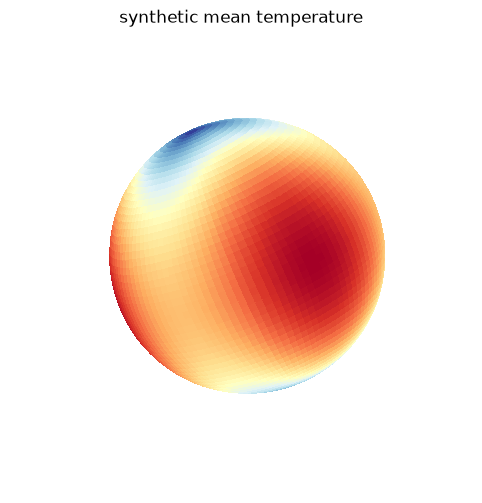

In [2]:
globe = TexturedGlobe.from_dataset(GLOBAL, cmap='RdYlBu_r', n_lon=120, n_lat=60)
fig, ax = globe.draw(spin=0.0)
ax.set_title('synthetic mean temperature')
print('texture:', globe.glyph.texture.shape, '| axial tilt:', globe.glyph.tilt_deg)

## 2. Spinning it — `spin`

`spin` rotates the sphere **about its own tilted polar axis**, which is what a planet actually does: the tilt
stays fixed in space while the surface turns underneath it. The texture is sampled once and cached, so each
extra frame is only a small matrix multiply — this is what makes the animation cheap.

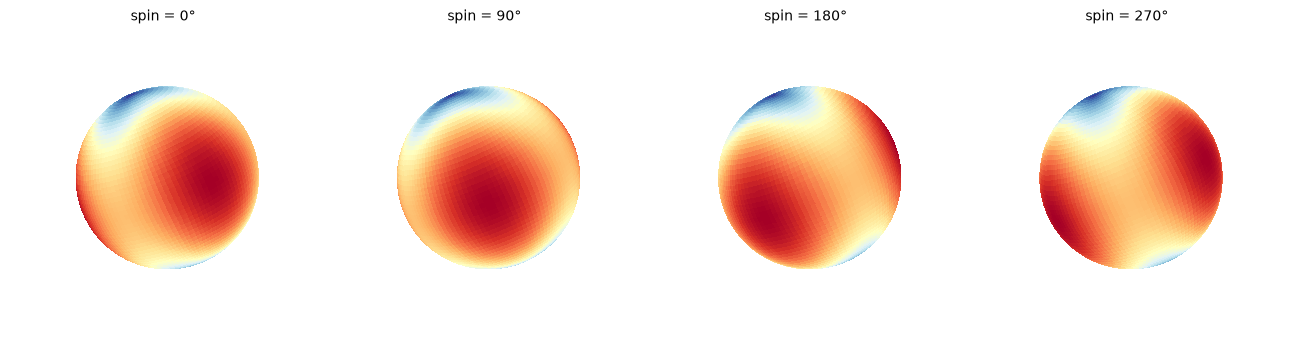

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), subplot_kw={'projection': '3d'})
for spin, sub in zip([0, 90, 180, 270], axes):
    globe.draw(ax=sub, spin=float(spin))
    sub.set_title(f'spin = {spin}°', fontsize=10)
fig.tight_layout()

## 3. Lighting — a day/night terminator

Pass a `sun` direction (a world-space vector, `+z` north and `+x` toward the viewer at `spin=0`) and the glyph
shades a lambertian terminator across the surface. `ambient` is the floor brightness kept on the night side so
it stays legible instead of going black.

Because the lighting is applied to the already-rotated vertices, a **fixed** sun sweeps the terminator as the
globe spins — exactly the behaviour you want for a day/night animation.

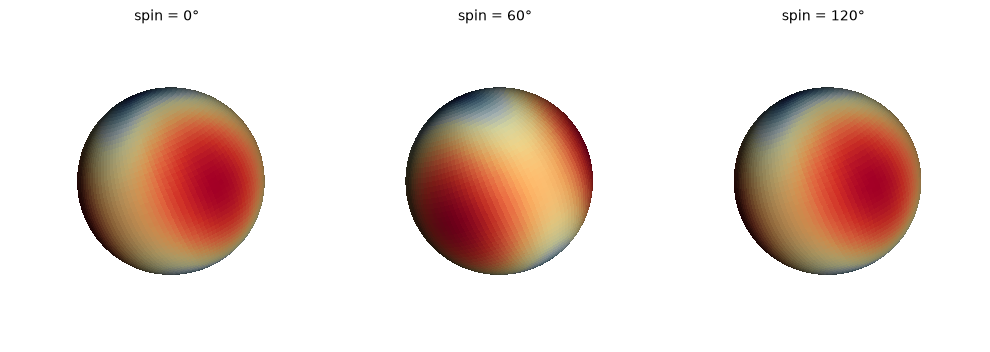

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.8), subplot_kw={'projection': '3d'})
for spin, sub in zip([0, 60, 120], axes):
    globe.draw(ax=sub, spin=float(spin), sun=(1.0, 0.35, 0.25), ambient=0.15)
    sub.set_title(f'spin = {spin}°', fontsize=10)
fig.tight_layout()

## 4. A regional raster lands where it belongs

This is the part cleopatra cannot do on its own: it takes a bare array and has no idea *where on Earth* it
goes. `from_dataset` reads the raster's own geotransform, so a regional dataset is pasted onto the globe at its
true lon/lat and everything it does not cover stays **transparent** — it is not stretched over the sphere.

`examples/data/acc4000.tif` is a small catchment in Colombia, in UTM 18N. pyramids reprojects it; the drape
lands near 75° W, 4° N.

In [5]:
catchment = Dataset.read_file(str(DATA / 'acc4000.tif'))
print('source CRS:', catchment.epsg, '| cells:', catchment.shape)

drape = TexturedGlobe.from_dataset(catchment, cmap='viridis', n_lon=120, n_lat=60)
alpha = drape.glyph.texture[..., 3]
rows, cols = np.nonzero(alpha > 0)
rows_lat = 90 - 180 * rows / (alpha.shape[0] - 1)
cols_lon = -180 + 360 * cols / (alpha.shape[1] - 1)
print(f'draped over lon {cols_lon.min():.2f}..{cols_lon.max():.2f}, '
      f'lat {rows_lat.min():.2f}..{rows_lat.max():.2f}')
print(f'opaque cells: {rows.size} of {alpha.size} — the rest of the globe is transparent')

source CRS: 32618 | cells: (1, 13, 14)


draped over lon -75.59..-75.21, lat 4.32..4.57
opaque cells: 8 of 4147200 — the rest of the globe is transparent


Only a handful of cells are opaque, because the catchment is about half a degree across on a 0.125° canvas.
That is the honest picture: a textured globe is a *planetary* renderer, and a small catchment is a few pixels
on it. Raise `shape=` for a finer canvas — and if the raster is smaller than a single canvas cell,
`from_dataset` warns rather than silently handing back a blank globe.

To actually *see* a small feature, put it on a global backdrop and point the camera at it.

Text(0.5, 0.92, 'the catchment (red) on the global field')

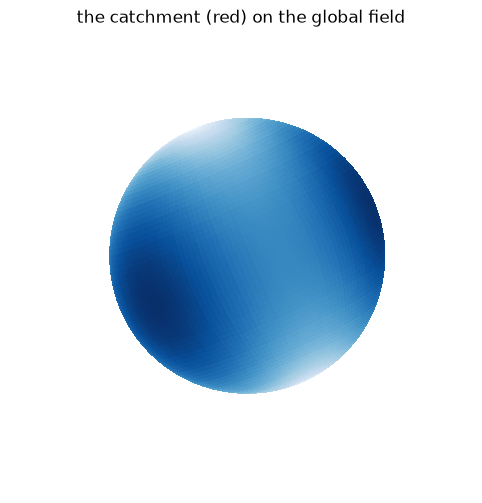

In [6]:
# Composite the catchment onto the global field's texture, then look at South America.
base = TexturedGlobe.from_dataset(GLOBAL, cmap='Blues', n_lon=160, n_lat=80)
mask = drape.glyph.texture[..., 3] > 0
composite = base.glyph.texture.copy()
composite[mask] = [1.0, 0.25, 0.1, 1.0]           # paint the catchment bright red
both = TexturedGlobe(composite, n_lon=160, n_lat=80)

fig, ax = both.draw(spin=-75.0, elev=5.0, azim=0.0)
ax.set_title('the catchment (red) on the global field')

## 5. Vector overlays — `project` and `points`

To draw anything *on* the sphere you need the same transform the glyph used for its mesh — spin **and** axial
tilt. `TexturedGlobe.project` pushes lon/lat through the glyph's own `transform`, so overlays sit exactly on
the drawn surface rather than drifting from it as you spin.

`points` builds on that: it accepts lon/lat arrays or a pyramids `FeatureCollection`, lifts the points slightly
off the surface so matplotlib does not z-fight them, and — by default — drops the ones on the far side, which
matplotlib would otherwise happily draw straight through the planet.

Text(0.5, 0.92, '7 of 8 cities are on the near side')

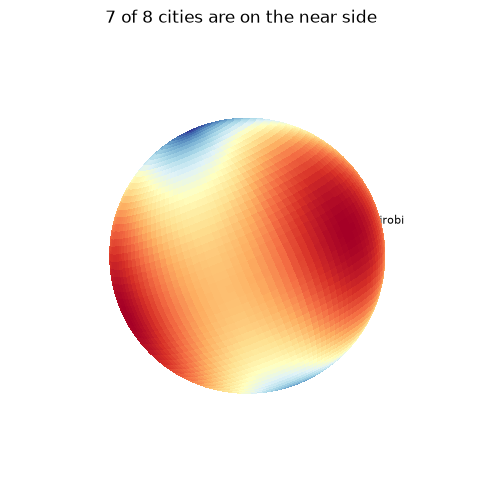

In [7]:
CITIES = {
    'Cairo': (31.2, 30.0), 'London': (-0.1, 51.5), 'Nairobi': (36.8, -1.3),
    'Reykjavik': (-21.9, 64.1), 'Lagos': (3.4, 6.5), 'Rome': (12.5, 41.9),
    'Sydney': (151.2, -33.9), 'Lima': (-77.0, -12.0),
}
city_lon = [v[0] for v in CITIES.values()]
city_lat = [v[1] for v in CITIES.values()]

SPIN = 20.0
fig, ax = globe.draw(spin=SPIN, elev=10.0, azim=0.0)
globe.points(city_lon, lat=city_lat, spin=SPIN, color='black', s=28, depthshade=False)

# Label only the ones actually facing us.
world = globe.project(city_lon, city_lat, spin=SPIN, altitude=0.06)
near = globe.visible(world)
for (name, _), xyz, shown in zip(CITIES.items(), world, near):
    if shown:
        ax.text(*xyz, name, fontsize=8)
ax.set_title(f'{int(near.sum())} of {len(CITIES)} cities are on the near side')

Spin the globe and a different set of cities faces the camera — the overlay follows the surface because it uses
the glyph's transform rather than a re-derived one.

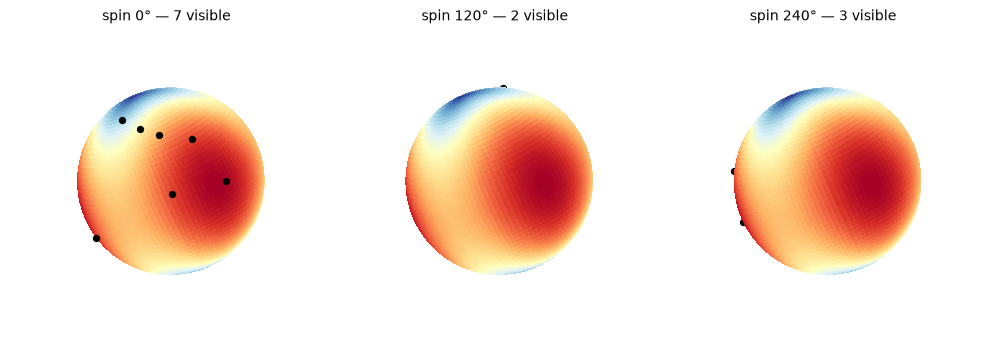

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.8), subplot_kw={'projection': '3d'})
for spin, sub in zip([0.0, 120.0, 240.0], axes):
    globe.draw(ax=sub, spin=spin)
    globe.points(city_lon, lat=city_lat, spin=spin, color='black', s=18, depthshade=False)
    visible = globe.visible(globe.project(city_lon, city_lat, spin=spin))
    sub.set_title(f'spin {int(spin)}° — {int(visible.sum())} visible', fontsize=10)
fig.tight_layout()

## 6. Animating a rotation

`animate` returns a matplotlib `FuncAnimation` over a full turn. Keep the mesh small here — every frame is a
full 3-D surface redraw, so resolution costs far more in an animation than in a still.

A fixed `sun` with a spinning globe gives the day/night sweep for free.

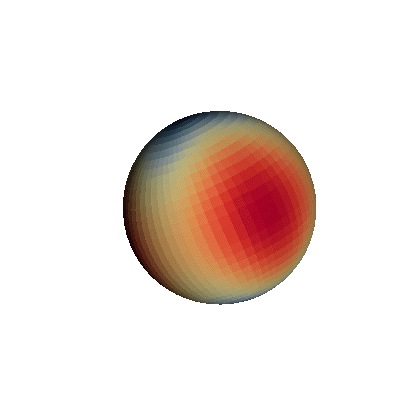

In [9]:
FPS = 8
spinner = TexturedGlobe.from_dataset(GLOBAL, cmap='RdYlBu_r', n_lon=64, n_lat=32,
                                     sun=(1.0, 0.3, 0.2), ambient=0.15)
anim = spinner.animate(n_frames=16, interval=1000 // FPS, figsize=(4.2, 4.2))
gif = embed_gif(anim, FPS)
plt.close(spinner.fig)   # avoid a duplicate static frame under %matplotlib inline
gif

## 7. Saving — render once, encode twice

Drawing frames costs far more than encoding them, so `save_animation` writes the clip and can **derive** a GIF
from that file instead of redrawing every frame:

```python
video, gif = spinner.save_animation('globe.mp4', gif='globe.gif')
```

The frames are rendered once. It also raises the intermediate video to full chroma (`yuv444p`) when a GIF is
being derived — the playback-friendly `yuv420p` default halves the colour resolution *before* the GIF palette
ever sees the frames, and that loss cannot be undone afterwards.

The same method is on `Map`, so a 2-D animation from notebook 12 saves identically.

In [10]:
out = Path(tempfile.mkdtemp())
written = spinner.save_animation(str(out / 'globe.gif'), fps=FPS)
print('wrote', Path(written).name, '-', Path(written).stat().st_size // 1024, 'KB')

wrote globe.gif - 283 KB


## 8. A brand mark — `stamp`

`stamp` places a logo or watermark in a corner of the **figure**, sized as a fraction of it, so it keeps its
proportion at whatever dpi you export at. It lives on `Scene`, so `Map` and the chart scenes have it too; the
globe exposes the same method.

Stamp **last** — the mark is baked from the figure's current size. And note `Scene.save` defaults to
`bbox_inches='tight'`, which crops whitespace and therefore shifts the mark; pass `bbox_inches=None` to keep
the placement exact.

Text(0.5, 0.92, 'with a corner brand mark')

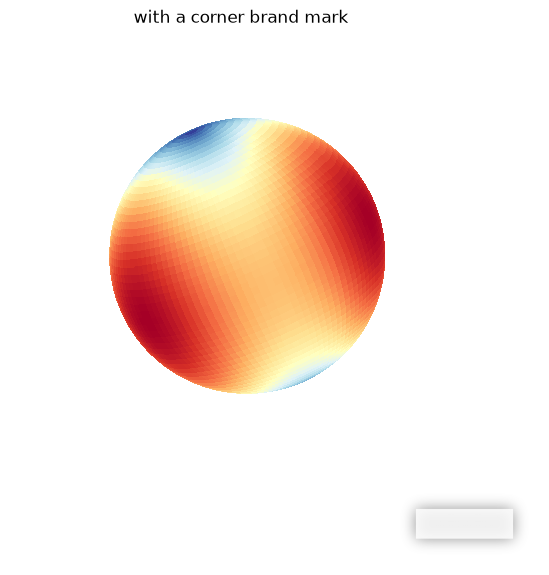

In [11]:
mark = np.zeros((60, 160, 4), dtype=np.uint8)
mark[8:52, 8:152, :3] = 255      # a plain white slab standing in for a logo
mark[8:52, 8:152, 3] = 220

fig, ax = globe.draw(spin=40.0)
globe.stamp(mark, frac=0.18, corner='lower right', shadow=True)
ax.set_title('with a corner brand mark')

## 9. A tile basemap as the texture — `from_provider`

`from_provider` fetches a whole-world XYZ basemap through cleopatra's `world_texture` and uses it as the
texture, which gives a photographic Earth:

```python
globe = TexturedGlobe.from_provider('Esri.WorldImagery', zoom=4, mesh_n_lon=180, mesh_n_lat=90)
globe.draw(spin=30.0, sun=(1.0, 0.3, 0.2))
```

Two things to know:

- It needs the network, and a whole-world fetch pulls **thousands** of tiles (`4**zoom`), so the texture is
  cached on disk per `(provider, zoom, n_lon, n_lat)`. It is not run in this notebook for that reason.
- Point it at a **bulk-permitting** provider. `Esri.WorldImagery` is the default; OpenStreetMap's usage policy
  forbids bulk downloading, so do not aim it there.
- `n_lon` / `n_lat` name the **texture** grid here (that is `world_texture`'s meaning); set the sphere mesh with
  `mesh_n_lon` / `mesh_n_lat`.

## Where to go next

- **Notebook 12** — the 2-D orthographic globe, `Map.animate` and `Map.rotate`, with coastlines and colorbars.
- **`docs/reference/textured_globe.md`** — the full `TexturedGlobe` API.
- **`docs/reference/animation.md`** — `save_animation`, shared by `Map` and `TexturedGlobe`.